In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

In [2]:
COVARIATE_FILE = "/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/All_combined_covariates.tsv"

COHOTRS = ["NYGC", "ROSMAP", "MSBB", "Mayo", "GTEx", "Answer_ALS"]

### Holdout ROSMAP DLPFC

In [3]:
covariates = pd.read_csv(COVARIATE_FILE, sep="\t")

In [4]:
# Filter for ROSMAP DLPFC samples
dlpfc = covariates[covariates['cohort_tissue'].str.contains('DLPFC')]
dlpfc = dlpfc[dlpfc['cohort'] == 'ROSMAP']

# Other samples
other = covariates[~covariates['cohort_tissue'].str.contains('DLPFC')]

# Get number of samples
print(f"Number of ROSMAP DLPFC samples: {len(dlpfc)}")

# Get number of participants
print(f"Number of ROSMAP DLPFC participants: {dlpfc['participant_id'].nunique()}")

print("Total number of samples: ", len(covariates))
print("Total number of ROSMAP samples : ", len(covariates[covariates['cohort'] == 'ROSMAP']))
print("Number of ROSMAP DLPFC samples: ", len(dlpfc))
print(f"Number of other samples: {len(other)}")


dlpfc.to_csv(os.path.join("/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/Test/covariates.tsv"), sep="\t", index=False)
other.to_csv(os.path.join("/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain/Processed/Train/covariates.tsv"), sep="\t", index=False)

Number of ROSMAP DLPFC samples: 719
Number of ROSMAP DLPFC participants: 719
Total number of samples:  7997
Total number of ROSMAP samples :  1821
Number of ROSMAP DLPFC samples:  719
Number of other samples: 7278


# Run extract_common_participants.py

In [11]:
! python extract_common_participants.py

/bin/bash: line 1: python: command not found


In [12]:
COVARIATE_FILE_TRAIN = os.path.join("/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain", "Processed", "Train", "covariates.tsv")
COVARIATE_FILE_TEST = os.path.join("/gpfs/commons/groups/knowles_lab/vmazeeva/BigBrain", "Processed", "Test", "covariates.tsv")

## After extraction of commont participants

In [13]:
train_covariates = pd.read_csv(COVARIATE_FILE_TRAIN, sep="\t")
test_covariates = pd.read_csv(COVARIATE_FILE_TEST, sep="\t")

covariates = pd.concat([train_covariates, test_covariates])
covariates.head()

,sample_id,participant_id,disease,estimated_sex,astrocyte,cohort_tissue,endothelial_cell,excitatory_neuron,inhibitory_neuron,microglia,...,picard_rnaseq_pct_correct_strand_reads,picard_rnaseq_median_cv_coverage,picard_rnaseq_median_5prime_bias,picard_rnaseq_median_3prime_bias,picard_rnaseq_median_5prime_to_3prime_bias,picard_rnaseq_sample,picard_rnaseq_library,picard_rnaseq_read_group,picard_rnaseq_pf_not_aligned_bases,cohort
0,CASE-NEUAE810KF7-9607-T,CASE-NEUAE810KF7-03884-G,ALS,Female,0.052992,Answer_ALS,0.083452,0.009797,0.000000,0.042848,...,0,0.338008,0.840712,0.958355,0.872336,NaN,NaN,NaN,255657331,AnswerALS
1,CASE-NEUAK233YVY-9803-T,CASE-NEUAK233YVY-03196-G,ALS,Male,0.000000,Answer_ALS,0.000000,0.176042,0.120913,0.106375,...,0,0.330415,0.854389,0.962960,0.872900,NaN,NaN,NaN,228998476,AnswerALS
2,CASE-NEUAL614GYB-8618-T,CASE-NEUYG636WT7-02544-G,ALS,Female,0.253586,Answer_ALS,0.275043,0.000000,0.000000,0.000000,...,0,0.393714,0.860410,0.841462,1.005228,NaN,NaN,NaN,447869573,AnswerALS
3,CASE-NEUAN180JPP-10533-T,CASE-NEUAN180JPP-03449-G,ALS,Male,0.473551,Answer_ALS,0.000000,0.000000,0.000000,0.120956,...,0,0.363057,0.854907,0.956136,0.882918,NaN,NaN,NaN,377919285,AnswerALS
4,CASE-NEUAP460GUX-10708-T,CASE-NEUAP460GUX-03815-G,ALS,Male,0.024013,Answer_ALS,0.272260,0.106377,0.081873,0.086397,...,0,0.347451,0.849756,0.971601,0.880470,NaN,NaN,NaN,415106397,AnswerALS


In [14]:
print("Train N samples: ", train_covariates['sample_id'].nunique())
print("Train N participants: ", train_covariates['participant_id'].nunique())
print("Test N samples: ", test_covariates['sample_id'].nunique())
print("Test N participants: ", test_covariates['participant_id'].nunique())


Train N samples:  7255
Train N participants:  2397
Test N samples:  710
Test N participants:  710


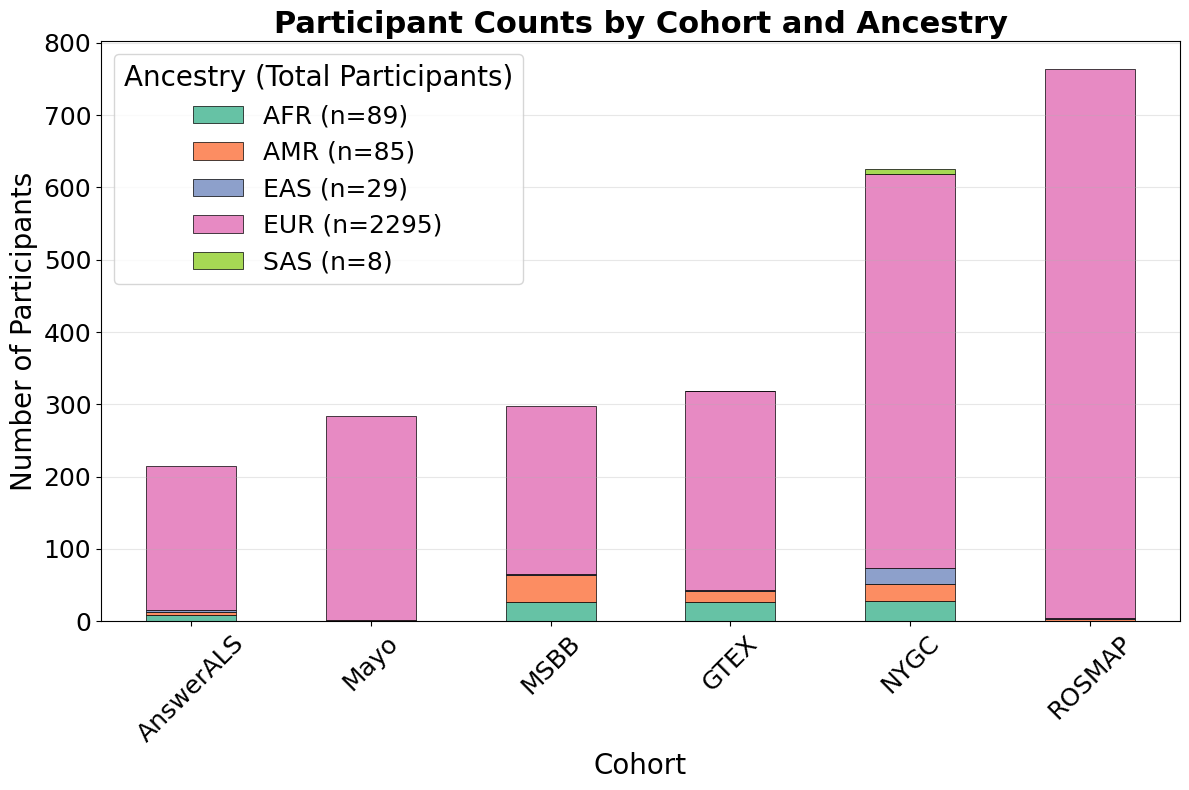

In [38]:
# Bar plot of participant counts per cohort, colored by ancestry
# Count unique participants per cohort and ancestry
participant_counts = covariates.groupby(['cohort', 'predicted_ancestry'], sort=True)['participant_id'].nunique().reset_index()
participant_counts.columns = ['cohort', 'ancestry', 'count']



# Pivot to create a matrix for stacked bar plot
pivot_data = participant_counts.pivot(index='cohort', columns='ancestry', values='count').fillna(0)

# Reorder cohorts: swap GTEX and Mayo positions
current_order = list(pivot_data.index)
# Find and swap GTEX and Mayo
gtex_pos = current_order.index('GTEX')
mayo_pos = current_order.index('Mayo')
new_order = current_order.copy()
new_order[gtex_pos], new_order[mayo_pos] = new_order[mayo_pos], new_order[gtex_pos]
pivot_data = pivot_data.reindex(new_order)

# Calculate total participants per ancestry across all cohorts for legend
ancestry_totals = covariates.groupby('predicted_ancestry')['participant_id'].nunique()

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette('Set2', n_colors=len(pivot_data.columns))
pivot_data.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', linewidth=0.5)

# Create custom legend with color codes and total counts
legend_labels = [f'{ancestry} (n={int(ancestry_totals[ancestry])})' for ancestry in pivot_data.columns]
ax.legend(legend_labels, title='Ancestry (Total Participants)', fontsize=18, loc='upper left', frameon=True, title_fontsize=20)

ax.set_title('Participant Counts by Cohort and Ancestry', fontsize=22, fontweight='bold')
ax.set_xlabel('Cohort', fontsize=20)
ax.set_ylabel('Number of Participants', fontsize=20)
ax.tick_params(axis='x', rotation=45, labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

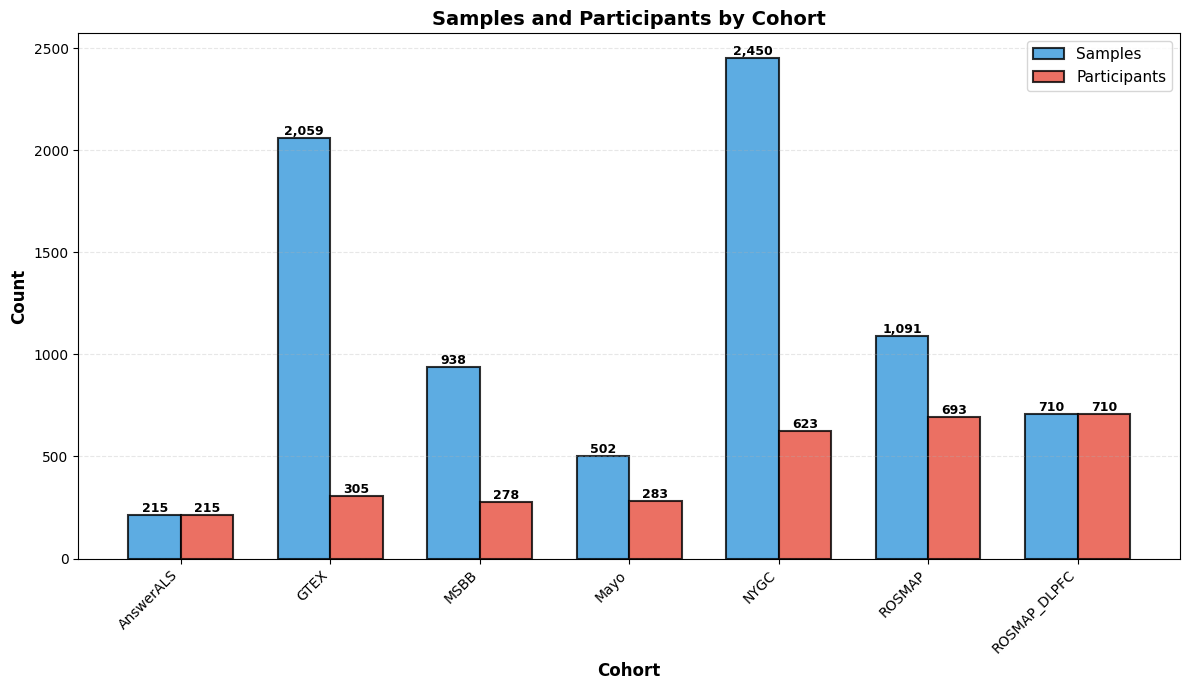


Summary by Cohort:
      Cohort  Samples  Participants
   AnswerALS      215           215
        GTEX     2059           305
        MSBB      938           278
        Mayo      502           283
        NYGC     2450           623
      ROSMAP     1091           693
ROSMAP_DLPFC      710           710


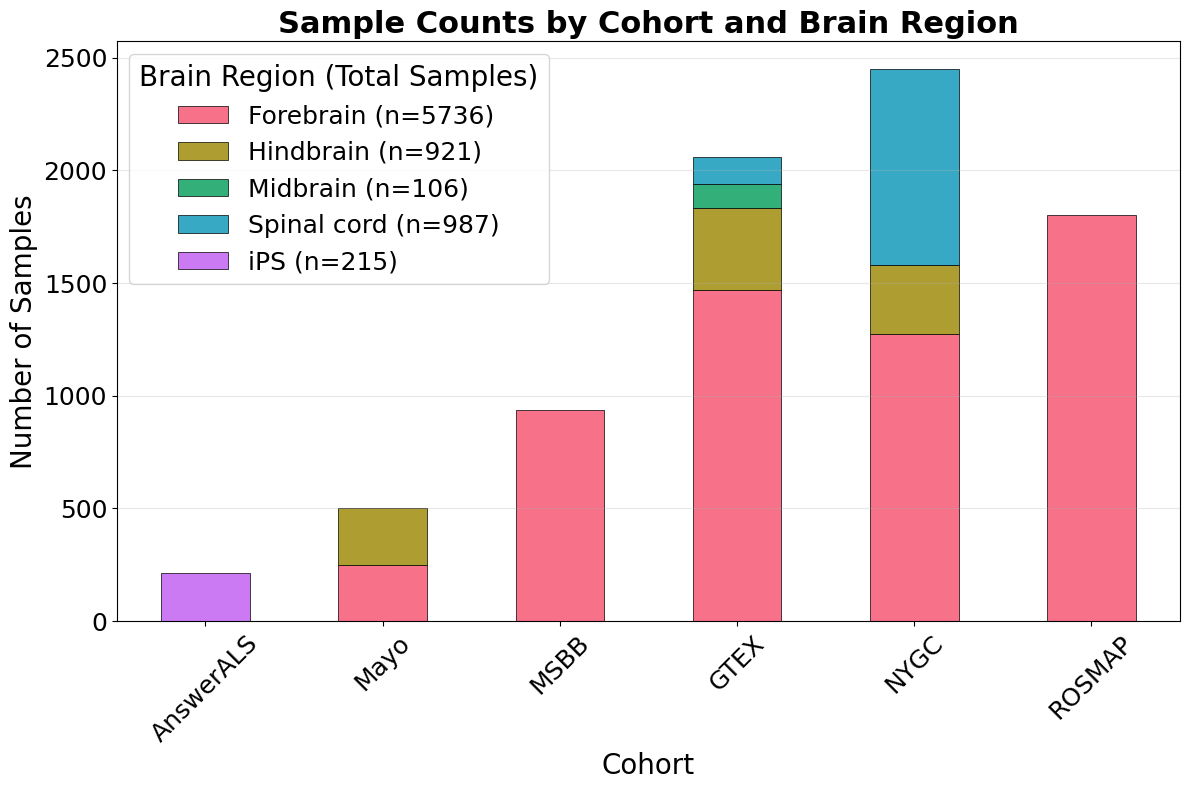

In [39]:

# Bar plot of sample counts per cohort, colored by brain region

# Count samples per cohort and brain region
sample_counts = covariates.groupby(['cohort', 'major_region'], sort=True).size().reset_index()
sample_counts.columns = ['cohort', 'brain_region', 'count']

# Pivot to create a matrix for stacked bar plot
pivot_data = sample_counts.pivot(index='cohort', columns='brain_region', values='count').fillna(0)

# Reorder cohorts: swap GTEX and Mayo positions
current_order = list(pivot_data.index)
# Find and swap GTEX and Mayo
gtex_pos = current_order.index('GTEX')
mayo_pos = current_order.index('Mayo')
new_order = current_order.copy()
new_order[gtex_pos], new_order[mayo_pos] = new_order[mayo_pos], new_order[gtex_pos]
pivot_data = pivot_data.reindex(new_order)

# Calculate total samples per brain region across all cohorts for legend
region_totals = covariates.groupby('major_region').size()

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette('husl', n_colors=len(pivot_data.columns))
pivot_data.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', linewidth=0.5)

# Create custom legend with color codes and total counts
legend_labels = [f'{region} (n={int(region_totals[region])})' for region in pivot_data.columns]
ax.legend(legend_labels, title='Brain Region (Total Samples)', loc='upper left', frameon=True, fontsize=18, title_fontsize=20)

ax.set_title('Sample Counts by Cohort and Brain Region', fontsize=22, fontweight='bold')
ax.set_xlabel('Cohort', fontsize=20)
ax.set_ylabel('Number of Samples', fontsize=20)
ax.tick_params(axis='x', rotation=45, labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## EDA: Covariates-Only Analysis 
(All Cohorts, Excluding ROSMAP DLPFC)


In [5]:

main_covariates = pd.read_csv(COVARIATE_FILE_TRAIN, sep="\t")

print(f"Non-holdout set (main set): {len(main_covariates)} samples")
print(f"Unique participants: {main_covariates['participant_id'].nunique()}")
print(f"\nCohorts included: {sorted(main_covariates['cohort'].unique())}")


Non-holdout set (main set): 7255 samples
Unique participants: 2397

Cohorts included: ['AnswerALS', 'GTEX', 'MSBB', 'Mayo', 'NYGC', 'ROSMAP']


In [6]:
main_covariates.head()

,sample_id,participant_id,disease,estimated_sex,astrocyte,cohort_tissue,endothelial_cell,excitatory_neuron,inhibitory_neuron,microglia,...,picard_rnaseq_pct_correct_strand_reads,picard_rnaseq_median_cv_coverage,picard_rnaseq_median_5prime_bias,picard_rnaseq_median_3prime_bias,picard_rnaseq_median_5prime_to_3prime_bias,picard_rnaseq_sample,picard_rnaseq_library,picard_rnaseq_read_group,picard_rnaseq_pf_not_aligned_bases,cohort
0,CASE-NEUAE810KF7-9607-T,CASE-NEUAE810KF7-03884-G,ALS,Female,0.052992,Answer_ALS,0.083452,0.009797,0.000000,0.042848,...,0,0.338008,0.840712,0.958355,0.872336,NaN,NaN,NaN,255657331,AnswerALS
1,CASE-NEUAK233YVY-9803-T,CASE-NEUAK233YVY-03196-G,ALS,Male,0.000000,Answer_ALS,0.000000,0.176042,0.120913,0.106375,...,0,0.330415,0.854389,0.962960,0.872900,NaN,NaN,NaN,228998476,AnswerALS
2,CASE-NEUAL614GYB-8618-T,CASE-NEUYG636WT7-02544-G,ALS,Female,0.253586,Answer_ALS,0.275043,0.000000,0.000000,0.000000,...,0,0.393714,0.860410,0.841462,1.005228,NaN,NaN,NaN,447869573,AnswerALS
3,CASE-NEUAN180JPP-10533-T,CASE-NEUAN180JPP-03449-G,ALS,Male,0.473551,Answer_ALS,0.000000,0.000000,0.000000,0.120956,...,0,0.363057,0.854907,0.956136,0.882918,NaN,NaN,NaN,377919285,AnswerALS
4,CASE-NEUAP460GUX-10708-T,CASE-NEUAP460GUX-03815-G,ALS,Male,0.024013,Answer_ALS,0.272260,0.106377,0.081873,0.086397,...,0,0.347451,0.849756,0.971601,0.880470,NaN,NaN,NaN,415106397,AnswerALS


1. COHORT DISTRIBUTION

Cohort sample distribution:
cohort
NYGC         2450
GTEX         2059
ROSMAP       1091
MSBB          938
Mayo          502
AnswerALS     215
Name: count, dtype: int64

Cohort sample percentages:
cohort
NYGC         33.77
GTEX         28.38
ROSMAP       15.04
MSBB         12.93
Mayo          6.92
AnswerALS     2.96
Name: count, dtype: float64


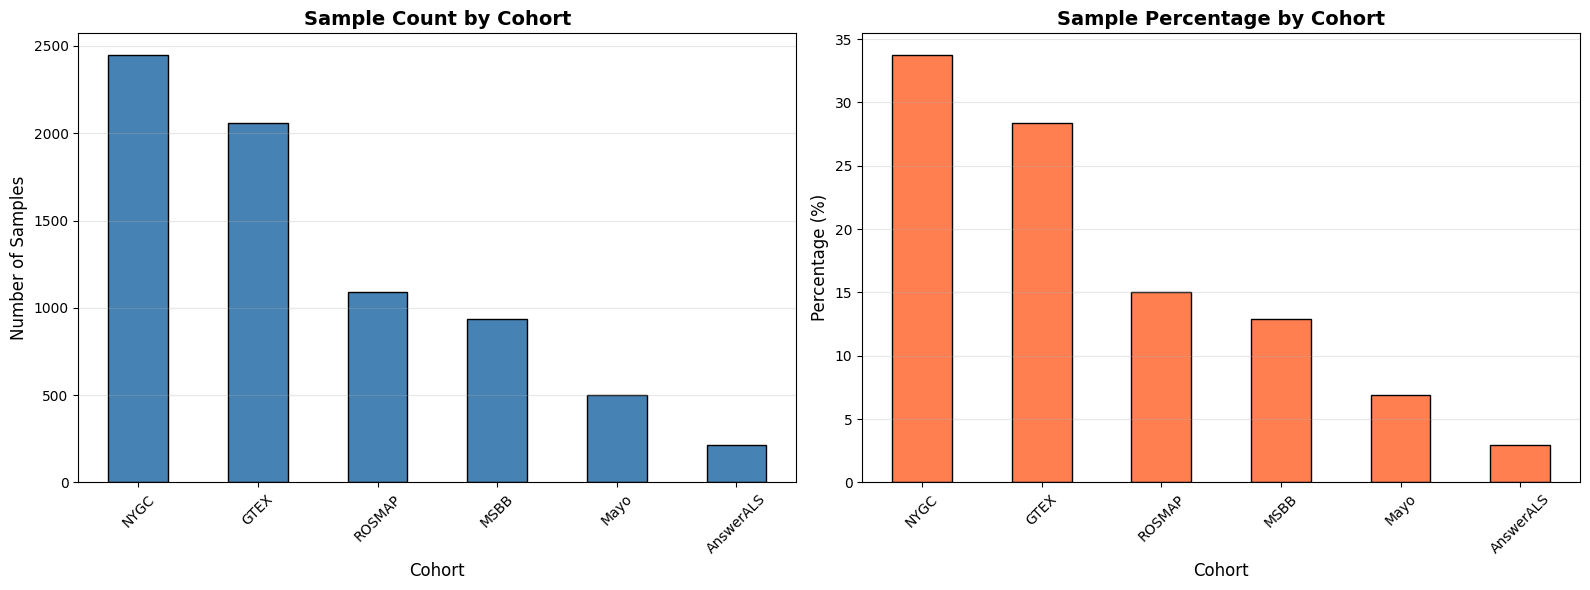


Cohort participant distribution:
cohort
AnswerALS    215
GTEX         305
MSBB         278
Mayo         283
NYGC         623
ROSMAP       693
Name: participant_id, dtype: int64

Cohort participant percentages:
cohort
AnswerALS    2.96
GTEX         4.20
MSBB         3.83
Mayo         3.90
NYGC         8.59
ROSMAP       9.55
Name: participant_id, dtype: float64


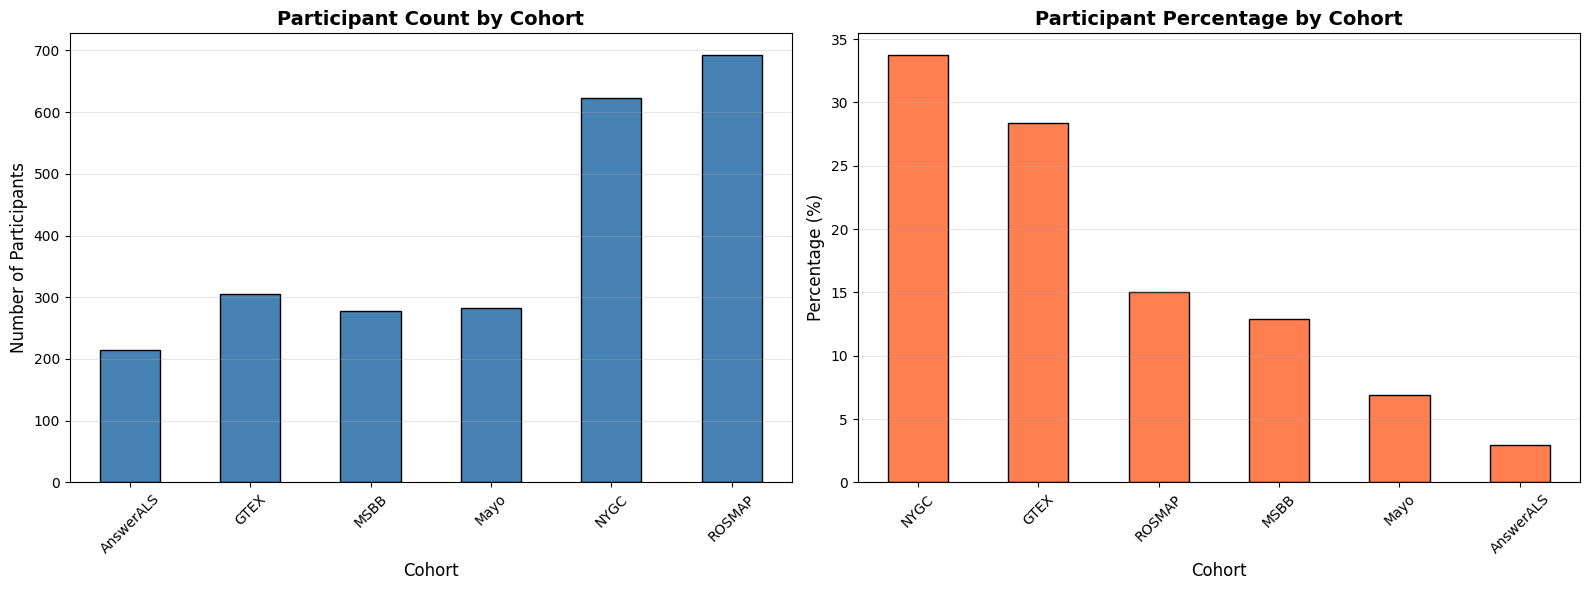

In [ ]:
# 1. Cohort Distribution
print("=" * 60)
print("1. COHORT DISTRIBUTION")
print("=" * 60)

cohort_counts = main_covariates['cohort'].value_counts()
print(f"\nCohort sample distribution:")
print(cohort_counts)
print(f"\nCohort sample percentages:")
print((cohort_counts / len(main_covariates) * 100).round(2))

# Plot cohort distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cohort_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Sample Count by Cohort', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cohort', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

(cohort_counts / len(main_covariates) * 100).plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Sample Percentage by Cohort', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cohort', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

cohort_participant_counts = main_covariates.groupby('cohort')['participant_id'].nunique()
print(f"\nCohort participant distribution:")
print(cohort_participant_counts)
print(f"\nCohort participant percentages:")
print((cohort_participant_counts / len(main_covariates) * 100).round(2))

# Plot cohort distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cohort_participant_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Participant Count by Cohort', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cohort', fontsize=12)
axes[0].set_ylabel('Number of Participants', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

(cohort_counts / len(main_covariates) * 100).plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Participant Percentage by Cohort', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cohort', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



2. COHORT_PAIR DISTRIBUTION
Created 'cohort_pair' from 'cohort' and 'cohort_tissue' columns

Cohort_pair distribution:
cohort_pair
ROSMAP_ROSMAP_batch2_HCN                 616
ROSMAP_ROSMAP_batch2_PCC                 475
NYGC_NYGC_Frontal_Cortex                 446
NYGC_NYGC_Cervical_Spinal_Cord           406
NYGC_NYGC_Lumbar_Spinal_Cord             383
NYGC_NYGC_Cerebellum                     306
MSBB_MSBB_FP_BA10                        252
Mayo_Mayo_TCX                            251
Mayo_Mayo_CBE                            251
MSBB_MSBB_STG_BA22                       237
MSBB_MSBB_IFG_BA44                       235
AnswerALS_Answer_ALS                     215
MSBB_MSBB_PG_BA36                        214
GTEX_GTEx_Cortex                         198
GTEX_GTEx_Cerebellum                     197
GTEX_GTEx_Nucleus                        194
NYGC_NYGC_Lateral_Motor_Cortex           187
NYGC_NYGC_Medial_Motor_Cortex            181
GTEX_GTEx_Caudate                        181
NYGC_NYGC_Moto

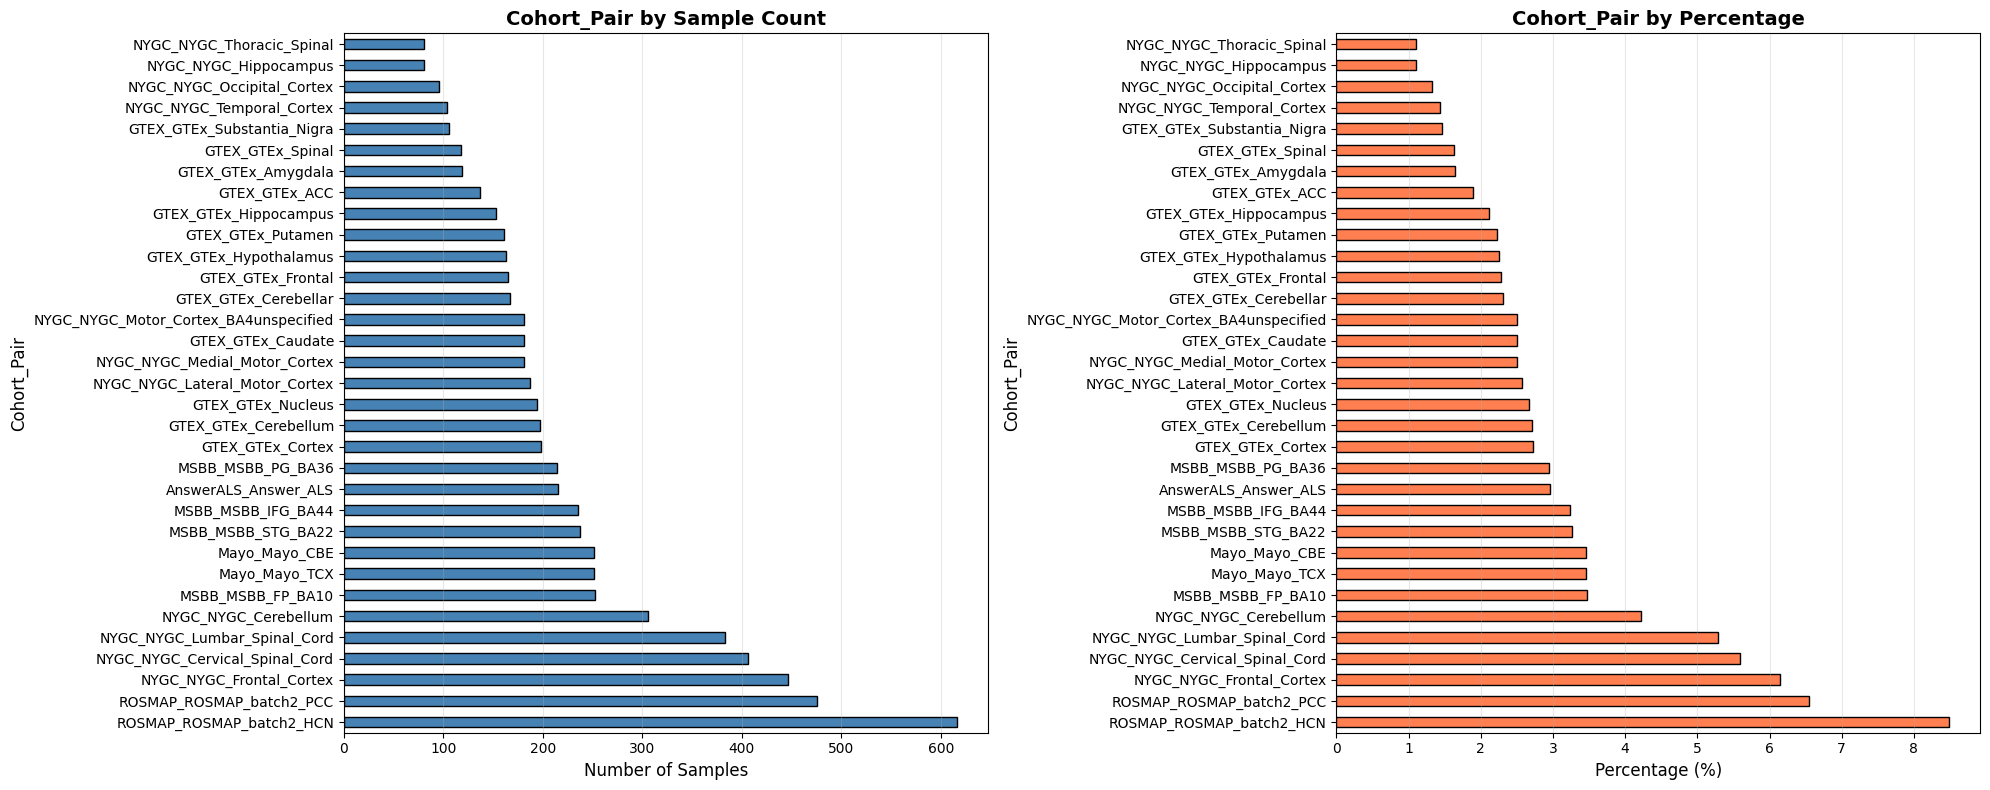

In [ ]:
# 2. Cohort_Pair Distribution (Cohort + Cohort_Tissue)
print("=" * 60)
print("2. COHORT_PAIR DISTRIBUTION")
print("=" * 60)

# Create cohort_pair from cohort and cohort_tissue
if 'cohort_tissue' in main_covariates.columns:
    main_covariates['cohort_pair'] = main_covariates['cohort'] + '_' + main_covariates['cohort_tissue'].astype(str)
    cohort_pair_col = 'cohort_pair'
    print("Created 'cohort_pair' from 'cohort' and 'cohort_tissue' columns")
else:
    cohort_pair_col = None
    print("Warning: 'cohort_tissue' column not found")

if cohort_pair_col:
    cohort_pair_counts = main_covariates[cohort_pair_col].value_counts()
    print(f"\nCohort_pair distribution:")
    print(cohort_pair_counts)
    print(f"\nTotal unique cohort_pair values: {len(cohort_pair_counts)}")
    
    # Plot cohort_pair distribution 
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    cohort_pair_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Cohort_Pair by Sample Count', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Number of Samples', fontsize=12)
    axes[0].set_ylabel('Cohort_Pair', fontsize=12)
    axes[0].grid(axis='x', alpha=0.3)
    
    (cohort_pair_counts / len(main_covariates) * 100).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('Cohort_Pair by Percentage', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Percentage (%)', fontsize=12)
    axes[1].set_ylabel('Cohort_Pair', fontsize=12)
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


3. ANCESTRY DISTRIBUTION

Ancestry distribution (predicted_ancestry):
predicted_ancestry
EUR    6546
AFR     377
AMR     241
EAS      58
SAS      33
Name: count, dtype: int64

Ancestry percentages:
predicted_ancestry
EUR    90.23
AFR     5.20
AMR     3.32
EAS     0.80
SAS     0.45
Name: count, dtype: float64


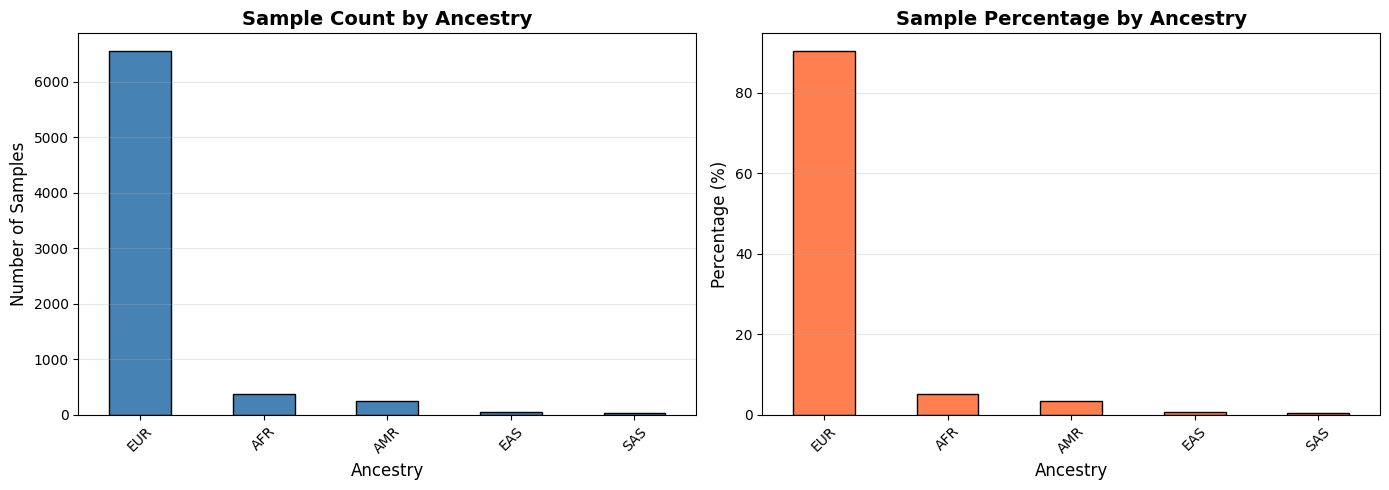

In [ ]:
# 3. Ancestry Distribution
print("=" * 60)
print("3. ANCESTRY DISTRIBUTION")
print("=" * 60)

# Check which ancestry column to use
ancestry_col = 'predicted_ancestry' if 'predicted_ancestry' in main_covariates.columns else 'given_ancestry'

if ancestry_col in main_covariates.columns:
    ancestry_counts = main_covariates[ancestry_col].value_counts()
    print(f"\nAncestry distribution ({ancestry_col}):")
    print(ancestry_counts)
    print(f"\nAncestry percentages:")
    print((ancestry_counts / len(main_covariates) * 100).round(2))
    
    # Plot ancestry distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ancestry_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Sample Count by Ancestry', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Ancestry', fontsize=12)
    axes[0].set_ylabel('Number of Samples', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    
    (ancestry_counts / len(main_covariates) * 100).plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('Sample Percentage by Ancestry', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Ancestry', fontsize=12)
    axes[1].set_ylabel('Percentage (%)', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: {ancestry_col} column not found in covariates")


4. MULTIPLE SAMPLES PER INDIVIDUAL

Total unique participants: 2409
Total samples: 7278
Average samples per participant: 3.02
Median samples per participant: 2
Max samples per participant: 13

Participants with multiple samples: 1692
Percentage of participants with multiple samples: 70.24%
Total samples from participants with multiple samples: 6561


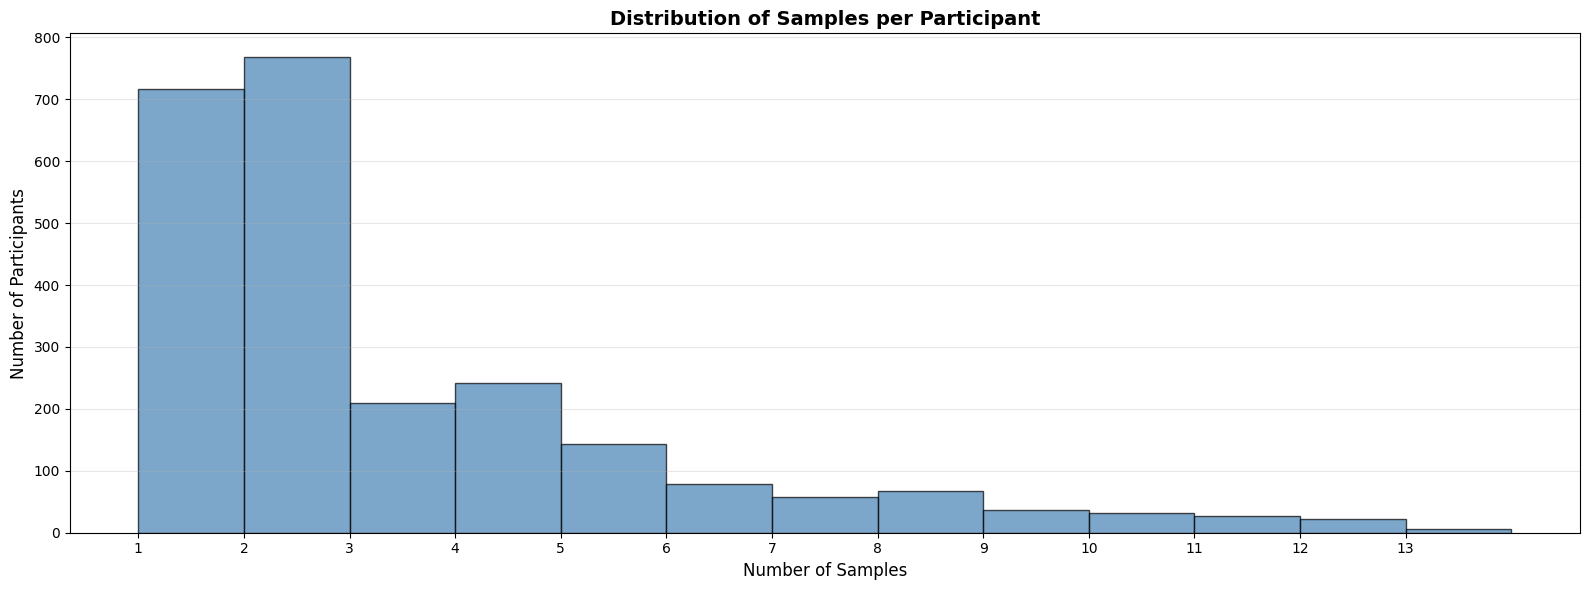

In [ ]:
# 4. Multiple Samples per Individual
print("=" * 60)
print("4. MULTIPLE SAMPLES PER INDIVIDUAL")
print("=" * 60)

# Count samples per participant
samples_per_participant = main_covariates.groupby('participant_id')['sample_id'].count().sort_values(ascending=False)
print(f"\nTotal unique participants: {len(samples_per_participant)}")
print(f"Total samples: {len(main_covariates)}")
print(f"Average samples per participant: {samples_per_participant.mean():.2f}")
print(f"Median samples per participant: {samples_per_participant.median():.0f}")
print(f"Max samples per participant: {samples_per_participant.max()}")

# Distribution of samples per participant
samples_per_participant_counts = samples_per_participant.value_counts().sort_index()


# Participants with multiple samples
multi_sample_participants = samples_per_participant[samples_per_participant > 1]
print(f"\nParticipants with multiple samples: {len(multi_sample_participants)}")
print(f"Percentage of participants with multiple samples: {len(multi_sample_participants) / len(samples_per_participant) * 100:.2f}%")
print(f"Total samples from participants with multiple samples: {multi_sample_participants.sum()}")

# Plot distribution
fig, ax = plt.subplots(figsize=(16, 6))

# Histogram of samples per participant
max_samples = min(samples_per_participant.max(), 50)  # Cap for readability
ax.hist(samples_per_participant.clip(upper=50), bins=range(1, max_samples + 2), 
        edgecolor='black', alpha=0.7, color='steelblue')
ax.set_title('Distribution of Samples per Participant', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Samples', fontsize=12)
ax.set_ylabel('Number of Participants', fontsize=12)
ax.set_xticks(range(1, max_samples + 1))
ax.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()



5. DEMOGRAPHIC CHARACTERISTICS

Age statistics:
  Mean: 69.61 years
  Median: 68.00 years
  Min: 16.00 years
  Max: 90.00 years
  Std: 14.67 years
  Missing values: 466 (6.40%)


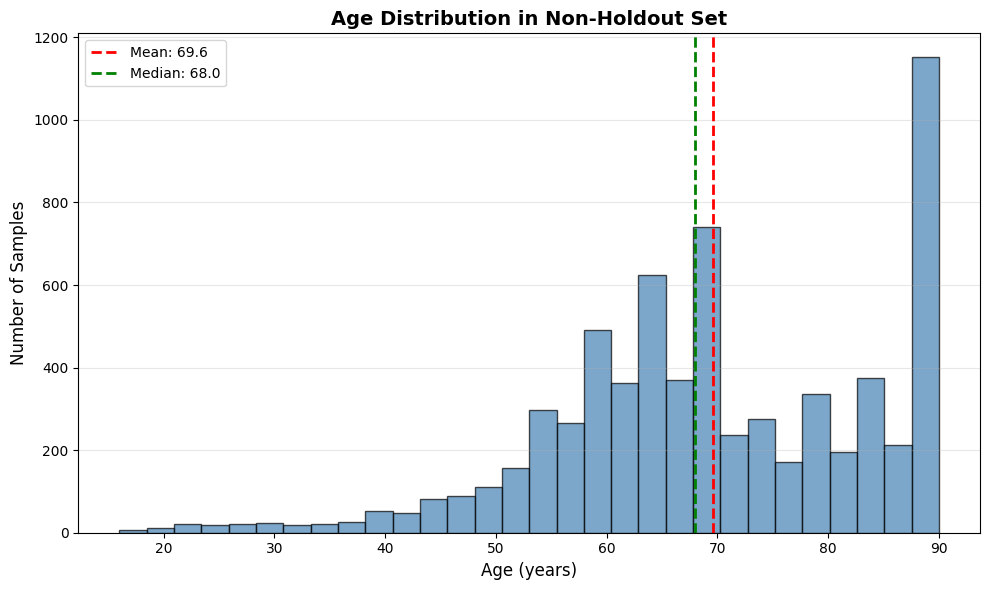


Sex distribution (biological_sex):
biological_sex
0    3674
1    3604
Name: count, dtype: int64

Sex percentages:
biological_sex
0    50.48
1    49.52
Name: count, dtype: float64


In [ ]:
# 5. Demographic Characteristics: Age and Sex
print("=" * 60)
print("5. DEMOGRAPHIC CHARACTERISTICS")
print("=" * 60)

# Age distribution
if 'age' in main_covariates.columns:
    age_data = pd.to_numeric(main_covariates['age'], errors='coerce')
    print(f"\nAge statistics:")
    print(f"  Mean: {age_data.mean():.2f} years")
    print(f"  Median: {age_data.median():.2f} years")
    print(f"  Min: {age_data.min():.2f} years")
    print(f"  Max: {age_data.max():.2f} years")
    print(f"  Std: {age_data.std():.2f} years")
    print(f"  Missing values: {age_data.isna().sum()} ({age_data.isna().sum() / len(age_data) * 100:.2f}%)")
    
    # Plot age distribution
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(age_data.dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(age_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {age_data.mean():.1f}')
    ax.axvline(age_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {age_data.median():.1f}')
    ax.set_title('Age Distribution in Non-Holdout Set', fontsize=14, fontweight='bold')
    ax.set_xlabel('Age (years)', fontsize=12)
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Sex distribution
sex_col = 'biological_sex' if 'biological_sex' in main_covariates.columns else 'estimated_sex'
if sex_col in main_covariates.columns:
    print(f"\nSex distribution ({sex_col}):")
    sex_counts = main_covariates[sex_col].value_counts()
    print(sex_counts)
    print(f"\nSex percentages:")
    print((sex_counts / len(main_covariates) * 100).round(2))
   

In [ ]:
# 7. Missing Data Patterns
print("=" * 60)
print("7. MISSING DATA PATTERNS")
print("=" * 60)

# Check missing data in key columns
key_cols = ['participant_id', 'sample_id', 'age', 'biological_sex', 'estimated_sex', 
            'predicted_ancestry', 'given_ancestry', 'cohort', 'cohort_tissue']

missing_data = {}
for col in key_cols:
    if col in main_covariates.columns:
        missing_count = main_covariates[col].isna().sum()
        missing_pct = missing_count / len(main_covariates) * 100
        missing_data[col] = {'missing': missing_count, 'percentage': missing_pct}

if missing_data:
    missing_df = pd.DataFrame(missing_data).T
    missing_df.columns = ['Missing Count', 'Missing Percentage']
    missing_df = missing_df.sort_values('Missing Percentage', ascending=False)
    print("\nMissing data in key columns:")
    print(missing_df)


7. MISSING DATA PATTERNS

Missing data in key columns:
                    Missing Count  Missing Percentage
given_ancestry             7278.0          100.000000
age                         466.0            6.402858
participant_id                0.0            0.000000
biological_sex                0.0            0.000000
sample_id                     0.0            0.000000
estimated_sex                 0.0            0.000000
predicted_ancestry            0.0            0.000000
cohort                        0.0            0.000000
cohort_tissue                 0.0            0.000000


8. TISSUE ANALYSIS
Using 'tissue' column

Analyzing tissue distribution...

Unique tissues: 26

Tissue counts:
tissue
Cerebellum                   754
cortex                       632
of caudate nucleus (HCN)     621
cortex (BA46)                611
cingulate cortex (PCC)       481
cord cervical                406
cord lumbar                  383
pole (BM10)                  255
temporal gyrus (BA22)        240
frontal gyrus (BA44)         237
Hippocampus                  233
gyrus (BA36)                 218
iPS                          215
Cortex                       198
accumbens (Basal ganglia)    194
cortex lateral               187
(basal ganglia)              181
cortex medial                181
Hemisphere                   167
Hypothalamus                 163
(Basal ganglia)              161
cingulate cortex (BA24)      137
Amygdala                     119
cord                         118
nigra                        106
cord thoracic                 80
Name: count, dtype: int6

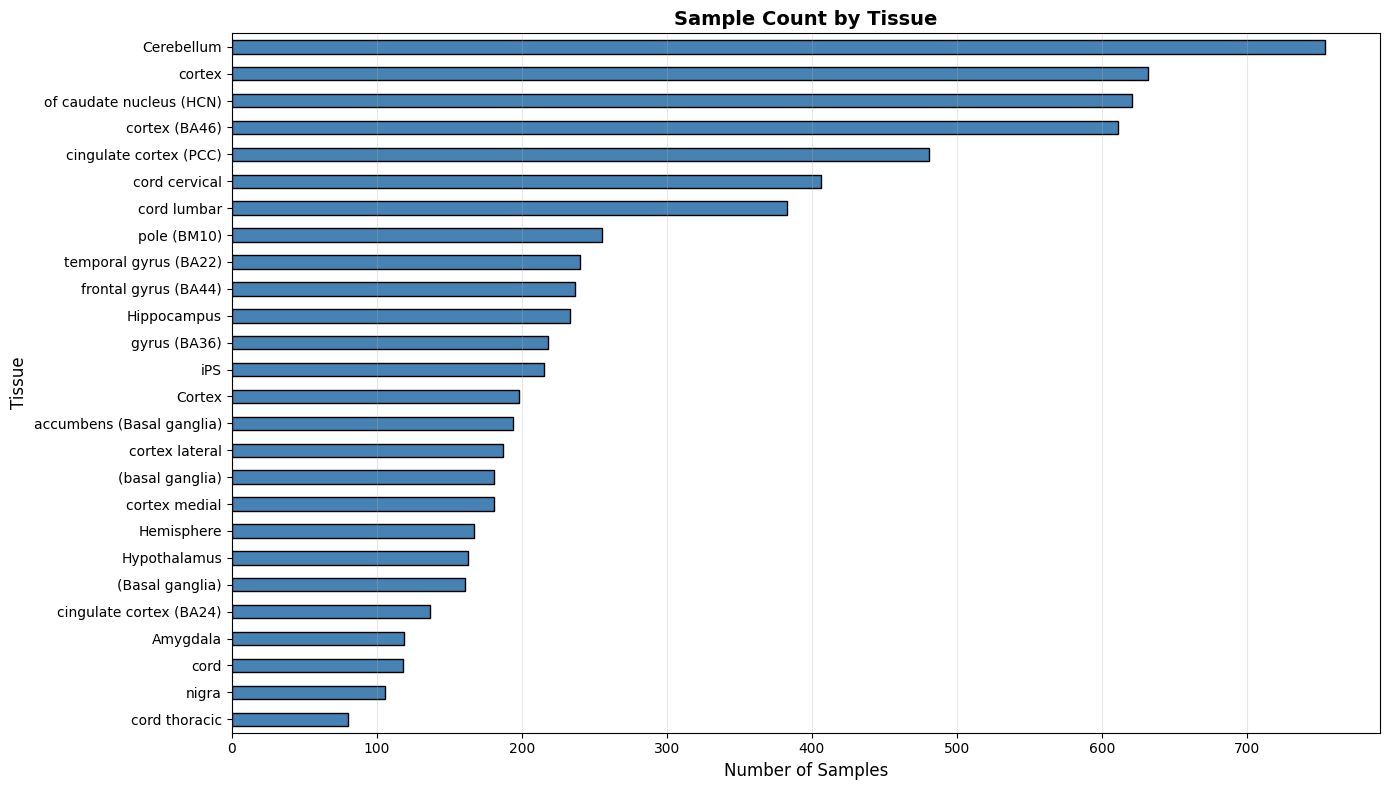


8b. INDIVIDUALS PER TISSUE (Histogram)

Unique participants per tissue:
tissue_cleaned
Cerebellum                   754
cortex                       630
of caudate nucleus (HCN)     621
cortex (BA46)                611
cingulate cortex (PCC)       481
cord cervical                406
cord lumbar                  383
pole (BM10)                  255
temporal gyrus (BA22)        240
frontal gyrus (BA44)         237
Hippocampus                  233
gyrus (BA36)                 218
iPS                          215
Cortex                       198
accumbens (Basal ganglia)    194
cortex lateral               187
cortex medial                181
(basal ganglia)              181
Hemisphere                   167
Hypothalamus                 163
(Basal ganglia)              161
cingulate cortex (BA24)      137
Amygdala                     119
cord                         118
nigra                        106
cord thoracic                 80
Name: participant_id, dtype: int64


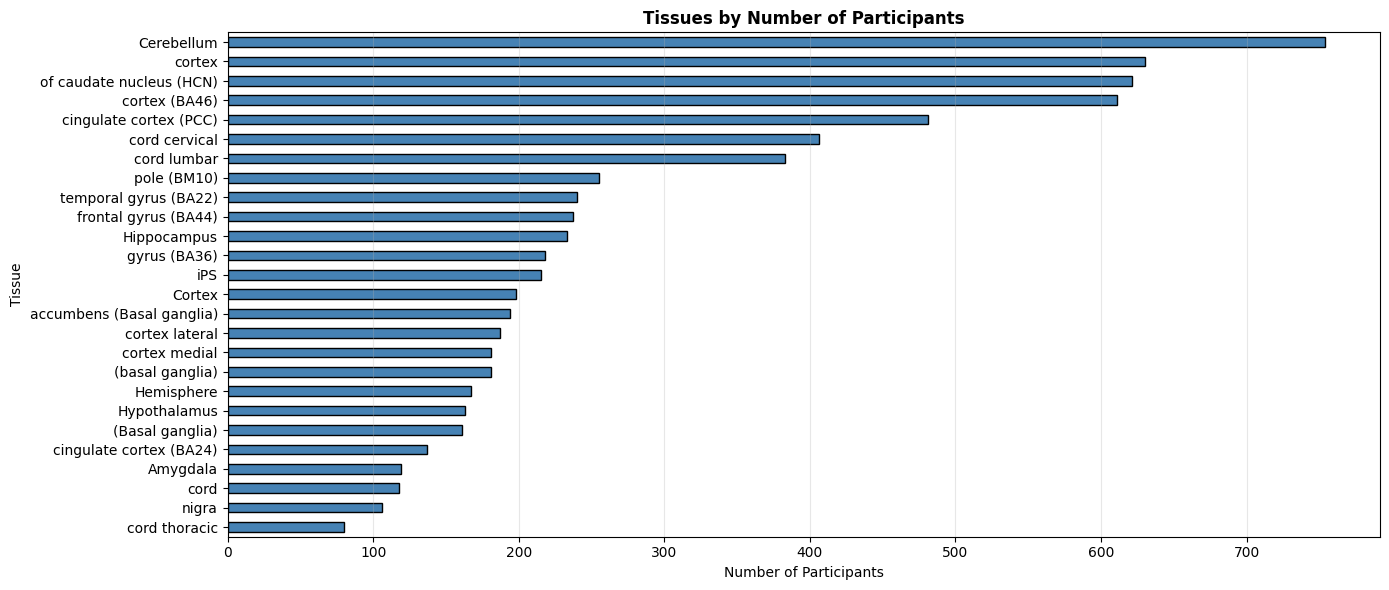


8c. HIERARCHICAL ORDER OF TISSUES

Found hierarchical columns: ['major_region', 'subregion']

Tissue hierarchy (showing top levels):

major_region distribution:
major_region
Forebrain      5049
Spinal cord     987
Hindbrain       921
iPS             215
Midbrain        106
Name: count, dtype: int64

subregion distribution:
subregion
Cortex                      3377
Subcortex, Basal ganglia     996
Spinal cord                  987
Cerebellum                   921
Subcortex, Limbic system     515
iPS                          215
Basal ganglia                161
Midbrain                     106
Name: count, dtype: int64

Hierarchical summary (top 20):
major_region                subregion  sample_count  unique_tissues
   Forebrain                   Cortex          3377              11
   Forebrain Subcortex, Basal ganglia           996               3
 Spinal cord              Spinal cord           987               4
   Hindbrain               Cerebellum           921               2
  

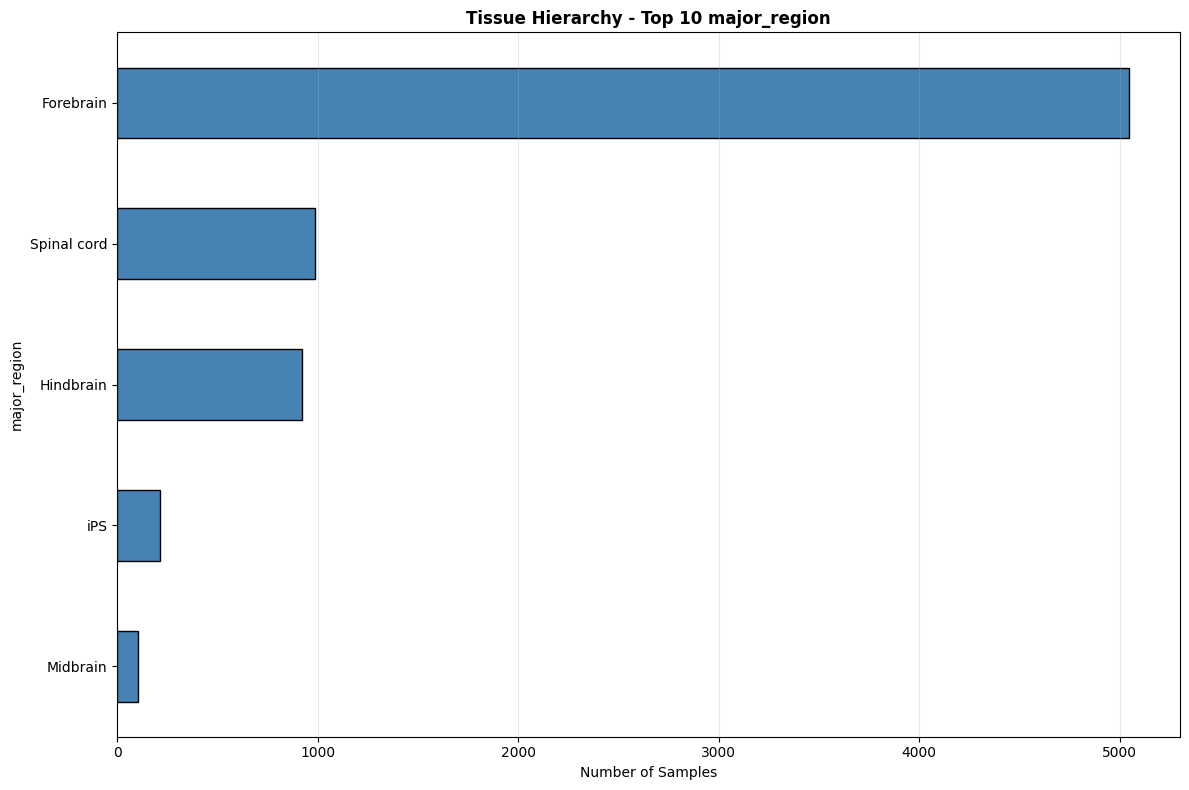


8d. CORRELATION ACROSS TISSUES

Participants with samples from multiple tissues: 1692
Percentage: 70.24%

Creating tissue co-occurrence matrix...

Top 20 most co-occurring tissue pairs (same participant):
               Tissue1                  Tissue2  count
cingulate cortex (PCC) of caudate nucleus (HCN)    401
            Cerebellum                   cortex    400
            Cerebellum            cortex (BA46)    384
         cord cervical              cord lumbar    357
                cortex            cortex (BA46)    301
         cord cervical            cortex (BA46)    296
           cord lumbar            cortex (BA46)    280
         cord cervical                   cortex    259
           cord lumbar                   cortex    239
  frontal gyrus (BA44)              pole (BM10)    222
           pole (BM10)    temporal gyrus (BA22)    221
  frontal gyrus (BA44)    temporal gyrus (BA22)    210
          gyrus (BA36)              pole (BM10)    200
            Cerebellum  

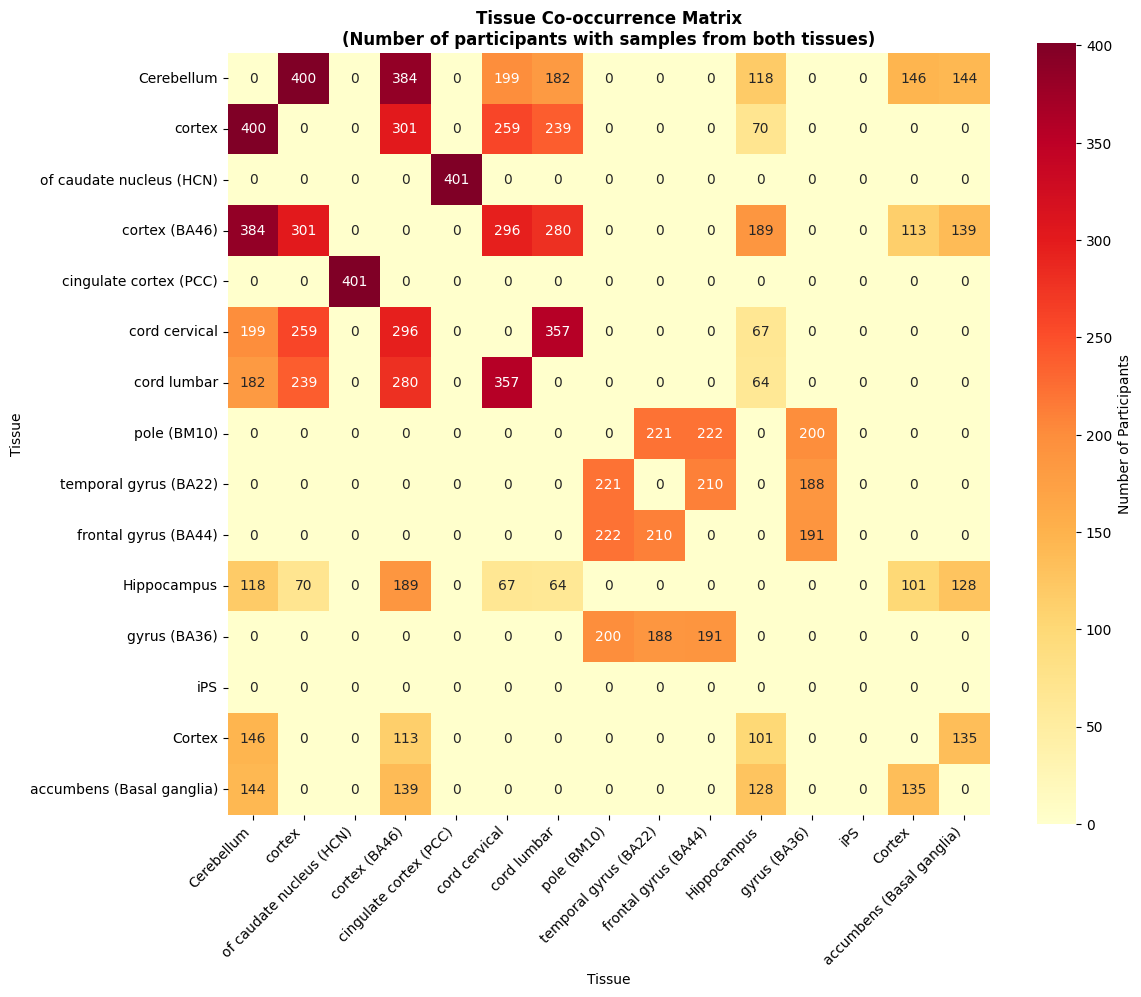


8e. DUPLICATE ANALYSIS - Participants with Multiple Samples per Tissue

Participants with multiple samples from the same tissue: 2
Total duplicate sample-tissue combinations: 2
9. SUMMARY STATISTICS

Non-Holdout Set Summary (Covariates Only):
  Total samples: 7278
  Unique participants: 2409
  Samples per participant (mean): 3.02
  Unique cohorts: 6
  Cohorts: AnswerALS, GTEX, MSBB, Mayo, NYGC, ROSMAP
  Unique ancestries: 5
  Most common ancestry: EUR
  Unique sexes: 2
  Age range: 16.0 - 90.0 years
  Age mean: 69.6 years
  Unique cohort_tissue values: 33


In [ ]:
# 8. Tissue Analysis
print("=" * 60)
print("8. TISSUE ANALYSIS")
print("=" * 60)

# Check which tissue column to use
tissue_col = None
if 'tissue' in main_covariates.columns:
    tissue_col = 'tissue'
    print("Using 'tissue' column")
elif 'cohort_tissue' in main_covariates.columns:
    tissue_col = 'cohort_tissue'
    print("Using 'cohort_tissue' column (may contain cohort-specific tissue names)")
else:
    print("Warning: No tissue column found")

if tissue_col:
    # Clean tissue names - remove cohort prefixes if present
    print(f"\nAnalyzing tissue distribution...")
    tissue_data = main_covariates[tissue_col].copy()
    
    # Remove cohort prefixes from tissue names (e.g., "ROSMAP_batch1_DLPFC" -> "DLPFC")
    # Try to extract just the tissue part
    tissue_cleaned = tissue_data.str.replace(r'^[A-Za-z_]+_', '', regex=True)
    tissue_cleaned = tissue_cleaned.str.replace(r'^[A-Za-z]+\s+', '', regex=True)  # Remove leading cohort names
    
    # Add cleaned tissue column to dataframe for easier grouping
    main_covariates['tissue_cleaned'] = tissue_cleaned
    
    # Count tissues
    tissue_counts = tissue_cleaned.value_counts()
    print(f"\nUnique tissues: {len(tissue_counts)}")
    print(f"\nTissue counts:")
    print(tissue_counts)
    
    # 8a. Bar plot of tissue counts
    print("\n" + "=" * 60)
    print("8a. TISSUE COUNTS (Bar Plot)")
    print("=" * 60)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    tissue_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title('Sample Count by Tissue', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Samples', fontsize=12)
    ax.set_ylabel('Tissue', fontsize=12)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 8b. Individuals per tissue (histogram)
    print("\n" + "=" * 60)
    print("8b. INDIVIDUALS PER TISSUE (Histogram)")
    print("=" * 60)
    
    # Count unique participants per tissue
    participants_per_tissue = main_covariates.groupby('tissue_cleaned')['participant_id'].nunique().sort_values(ascending=False)
    print(f"\nUnique participants per tissue:")
    print(participants_per_tissue)

  
    # Bar plot of top tissues by participant count
    fig, ax = plt.subplots(figsize=(14, 6))
    participants_per_tissue.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title('Tissues by Number of Participants', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Participants', fontsize=10)
    ax.set_ylabel('Tissue', fontsize=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 8c. Hierarchical order of tissues
    print("\n" + "=" * 60)
    print("8c. HIERARCHICAL ORDER OF TISSUES")
    print("=" * 60)
    
    # Check if there are hierarchical tissue columns (major_region, subregion, etc.)
    hierarchical_cols = []
    if 'major_region' in main_covariates.columns:
        hierarchical_cols.append('major_region')
    if 'subregion' in main_covariates.columns:
        hierarchical_cols.append('subregion')
    if 'tissue' in main_covariates.columns and tissue_col != 'tissue':
        hierarchical_cols.append('tissue')
    
    if hierarchical_cols:
        print(f"\nFound hierarchical columns: {hierarchical_cols}")
        
        # Create hierarchical grouping
        hierarchical_data = main_covariates[hierarchical_cols + ['tissue_cleaned']].copy()
        hierarchical_data.columns = hierarchical_cols + ['tissue']
        
        # Show hierarchy
        print("\nTissue hierarchy (showing top levels):")
        for col in hierarchical_cols:
            print(f"\n{col} distribution:")
            print(hierarchical_data[col].value_counts().head(10))
        
        # Create a hierarchical tree structure
        if len(hierarchical_cols) >= 2:
            hierarchy_summary = hierarchical_data.groupby(hierarchical_cols)['tissue'].agg(['count', 'nunique']).reset_index()
            hierarchy_summary.columns = hierarchical_cols + ['sample_count', 'unique_tissues']
            hierarchy_summary = hierarchy_summary.sort_values('sample_count', ascending=False)
            
            print(f"\nHierarchical summary (top 20):")
            print(hierarchy_summary.head(20).to_string(index=False))
            
            # Visualize hierarchy
            fig, ax = plt.subplots(figsize=(12, 8))
            # Create a simplified hierarchy visualization
            top_regions = hierarchical_data[hierarchical_cols[0]].value_counts().head(10)
            top_regions.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
            ax.set_title(f'Tissue Hierarchy - Top 10 {hierarchical_cols[0]}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Number of Samples', fontsize=10)
            ax.set_ylabel(hierarchical_cols[0], fontsize=10)
            ax.invert_yaxis()
            ax.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()
    else:
        print("\nNo hierarchical columns found. Using tissue counts as hierarchy.")
        # Use tissue counts as a simple hierarchy
        print("\nTissue hierarchy (by sample count):")
        print(tissue_counts.head(20))
    
    # 8d. Correlation across tissues
    print("\n" + "=" * 60)
    print("8d. CORRELATION ACROSS TISSUES")
    print("=" * 60)
    
    # For correlation analysis, we need to look at participants who have multiple tissues
    # Count how many participants have samples from multiple tissues
    participant_tissues = main_covariates.groupby('participant_id')['tissue_cleaned'].apply(lambda x: set(x.dropna()))
    participants_multiple_tissues = participant_tissues[participant_tissues.apply(len) > 1]
    
    print(f"\nParticipants with samples from multiple tissues: {len(participants_multiple_tissues)}")
    print(f"Percentage: {len(participants_multiple_tissues) / len(participant_tissues) * 100:.2f}%")
    
    if len(participants_multiple_tissues) > 0:
        # Create a tissue co-occurrence matrix
        print("\nCreating tissue co-occurrence matrix...")
        tissue_pairs = []
        for participant, tissues in participants_multiple_tissues.items():
            tissues_list = sorted(list(tissues))
            for i in range(len(tissues_list)):
                for j in range(i+1, len(tissues_list)):
                    tissue_pairs.append((tissues_list[i], tissues_list[j]))
        
        if tissue_pairs:
            tissue_pairs_df = pd.DataFrame(tissue_pairs, columns=['Tissue1', 'Tissue2'])
            tissue_cooccurrence = tissue_pairs_df.groupby(['Tissue1', 'Tissue2']).size().reset_index(name='count')
            tissue_cooccurrence = tissue_cooccurrence.sort_values('count', ascending=False)
            
            print(f"\nTop 20 most co-occurring tissue pairs (same participant):")
            print(tissue_cooccurrence.head(20).to_string(index=False))
            
            # Create a tissue correlation/co-occurrence matrix
            all_tissues = sorted(set(main_covariates['tissue_cleaned'].dropna()))
            cooccurrence_matrix = pd.DataFrame(0, index=all_tissues, columns=all_tissues)
            
            for _, row in tissue_cooccurrence.iterrows():
                t1, t2 = row['Tissue1'], row['Tissue2']
                cooccurrence_matrix.loc[t1, t2] = row['count']
                cooccurrence_matrix.loc[t2, t1] = row['count']
            
            # Plot heatmap (top tissues)
            top_tissues_for_heatmap = tissue_counts.head(15).index.tolist()
            cooccurrence_subset = cooccurrence_matrix.loc[top_tissues_for_heatmap, top_tissues_for_heatmap]
            
            fig, ax = plt.subplots(figsize=(12, 10))
            sns.heatmap(cooccurrence_subset, annot=True, fmt='d', cmap='YlOrRd', 
                       square=True, cbar_kws={'label': 'Number of Participants'}, ax=ax)
            ax.set_title('Tissue Co-occurrence Matrix\n(Number of participants with samples from both tissues)', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Tissue', fontsize=10)
            ax.set_ylabel('Tissue', fontsize=10)
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()
    
    # 8e. Duplicate analysis
    print("\n" + "=" * 60)
    print("8e. DUPLICATE ANALYSIS - Participants with Multiple Samples per Tissue")
    print("=" * 60)
    
    # Count samples per participant per tissue
    participant_tissue_counts = main_covariates.groupby(['participant_id', 'tissue_cleaned']).size().reset_index(name='sample_count')
    participant_tissue_counts = participant_tissue_counts.sort_values('sample_count', ascending=False)
    
    # Participants with multiple samples of the same tissue
    duplicates = participant_tissue_counts[participant_tissue_counts['sample_count'] > 1]
    
    print(f"\nParticipants with multiple samples from the same tissue: {len(duplicates)}")
    print(f"Total duplicate sample-tissue combinations: {duplicates['sample_count'].sum() - len(duplicates)}")
    
    

# 9. Summary Statistics
print("=" * 60)
print("9. SUMMARY STATISTICS")
print("=" * 60)

print(f"\nNon-Holdout Set Summary (Covariates Only):")
print(f"  Total samples: {len(main_covariates)}")
print(f"  Unique participants: {main_covariates['participant_id'].nunique()}")
print(f"  Samples per participant (mean): {len(main_covariates) / main_covariates['participant_id'].nunique():.2f}")

if 'cohort' in main_covariates.columns:
    print(f"  Unique cohorts: {main_covariates['cohort'].nunique()}")
    print(f"  Cohorts: {', '.join(sorted(main_covariates['cohort'].unique()))}")

if ancestry_col in main_covariates.columns:
    print(f"  Unique ancestries: {main_covariates[ancestry_col].nunique()}")
    print(f"  Most common ancestry: {main_covariates[ancestry_col].mode()[0] if len(main_covariates[ancestry_col].mode()) > 0 else 'N/A'}")

if sex_col in main_covariates.columns:
    print(f"  Unique sexes: {main_covariates[sex_col].nunique()}")

if 'age' in main_covariates.columns:
    age_data = pd.to_numeric(main_covariates['age'], errors='coerce')
    print(f"  Age range: {age_data.min():.1f} - {age_data.max():.1f} years")
    print(f"  Age mean: {age_data.mean():.1f} years")

if 'cohort_tissue' in main_covariates.columns:
    print(f"  Unique cohort_tissue values: {main_covariates['cohort_tissue'].nunique()}")

